# Route-3 7D Preregistration and Independent Robustness

This notebook freezes and verifies the independent seven-free-parameter
experiment. `c_ctx2th` is fixed by the deterministic V8a-local-best rule before
new simulations. The observable remains the frozen 14D **cortical population
firing-rate** summary; it is not simulated EEG and does not resolve the Fpz-Cz
measurement-model blocker.

The engineering hard gate is evaluated before the 4,096-row training bank.
Scientific warnings such as collisions or ridges are retained without changing
the preregistered design.

In [1]:
from __future__ import annotations
from datetime import datetime, timezone
import importlib.metadata as mdist
import json
import os
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "S4_sbi" / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "S4_sbi" / "src").exists():
            PROJECT_ROOT = parent
            break
for value in (PROJECT_ROOT / "S4_sbi" / "src", PROJECT_ROOT):
    if str(value) not in sys.path:
        sys.path.insert(0, str(value))

environment = {
    "executed_utc": datetime.now(timezone.utc).isoformat(),
    "conda_environment": os.environ.get("CONDA_DEFAULT_ENV"),
    "sys.executable": sys.executable,
    "sys.prefix": sys.prefix,
    "python": platform.python_version(),
    "kernel_id": "neurolib",
    "kernel_display_name": "Python (neurolib)",
    "numpy": mdist.version("numpy"),
    "torch": mdist.version("torch"),
    "sbi": mdist.version("sbi"),
    "neurolib": mdist.version("neurolib"),
}
assert Path(sys.prefix).name.lower() == "neurolib"
display(pd.DataFrame(environment.items(), columns=["item", "value"]))

,item,value
0,executed_utc,2026-07-28T00:50:12.427090+00:00
1,conda_environment,neurolib
2,sys.executable,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...
3,sys.prefix,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...
4,python,3.10.20
5,kernel_id,neurolib
6,kernel_display_name,Python (neurolib)
7,numpy,2.2.6
8,torch,2.5.1
9,sbi,0.26.1


In [2]:
from sleep_sbi.route3_7d_experiment import *

prereg_hash = verify_preregistration()
prereg = read_preregistration()
print("Preregistration SHA-256:", prereg_hash)
display(pd.DataFrame({
    "parameter": prereg["parameter_order_7d"],
    "unit": prereg["parameter_units_7d"],
    "lower": [row[0] for row in prereg["prior_bounds_7d"]],
    "upper": [row[1] for row in prereg["prior_bounds_7d"]],
}))
display(pd.DataFrame([prereg["fixed_parameter"]]))
assert prereg["fixed_parameter"]["selection_rule"].startswith("Notebook 10")
assert prereg["seed_nonoverlap_audit"]["intersection_count"] == 0

Preregistration SHA-256: 2cedb6a68de307ab2f9233b4009a8f58854316259b6c185aeb61af5efdcbc363


,parameter,unit,lower,upper
0,mue,mV/ms,3.31075,4.47925
1,mui,mV/ms,2.57295,3.48105
2,b,pA,28.40000,42.60000
3,tauA,ms,998.20000,1853.80000
4,g_LK,mS/cm^2,0.02000,0.07000
5,g_h,mS/cm^2,0.03500,0.09500
6,c_th2ctx,dimensionless coupling,0.00000,0.07500


,name,value,unit,selection_rule,source,source_sha256,prior_range,inside_old_8d_prior,conditional_claim
0,c_ctx2th,0.125349,dimensionless coupling,Notebook 10 canonical V8a local best; no recov...,outputs/v8a_ultra_narrow_t6_t13_search/best_so...,bf18212ebac0ebec39d4f13aecd5b7a9da5618ffe78abb...,"[0.05, 0.22]",True,All seven-parameter conclusions are conditiona...


## Independent 128 x 3 prior-wide seed experiment

Each of 128 new Sobol parameter vectors is simulated with three new stochastic
seeds. Replicates are stored separately. The between-theta/within-theta variance
ratio measures parameter signal relative to simulator-seed noise; it does not
prove posterior identifiability.

,attempted,success,failure_rate,finite_rate,noise_floor_q95,nearest_neighbor_all_three_agreement,nearest_neighbor_pair_agreement_mean,collision_count,near_collision_count
0,384,384,0.0,1.0,2.708794,0.257812,0.416667,2106,3869


,feature,within_theta_seed_variance,between_theta_variance,between_to_within_snr,unique_values_min_across_seeds,quantized_or_degenerate_warning
0,r_exc_mean_hz,0.003725,4.492087,1205.908908,128,False
1,r_exc_std_hz,0.009611,4.053745,421.784397,128,False
2,r_exc_relative_so_power,0.000174,0.023848,136.811734,128,False
3,r_exc_relative_sigma_power,0.000019,0.001069,56.107861,128,False
4,r_exc_so_peak_frequency_hz,0.004557,0.087509,19.202006,5,True
5,r_exc_sigma_peak_frequency_hz,0.218262,0.362174,1.659354,12,True
6,r_exc_spectral_entropy_0p5_20,0.000080,0.003071,38.154527,128,False
7,r_inh_mean_hz,0.074378,92.380761,1242.049244,128,False
8,r_inh_std_hz,0.034831,6.937513,199.176600,128,False
9,r_inh_relative_so_power,0.000313,0.039722,126.815216,128,False


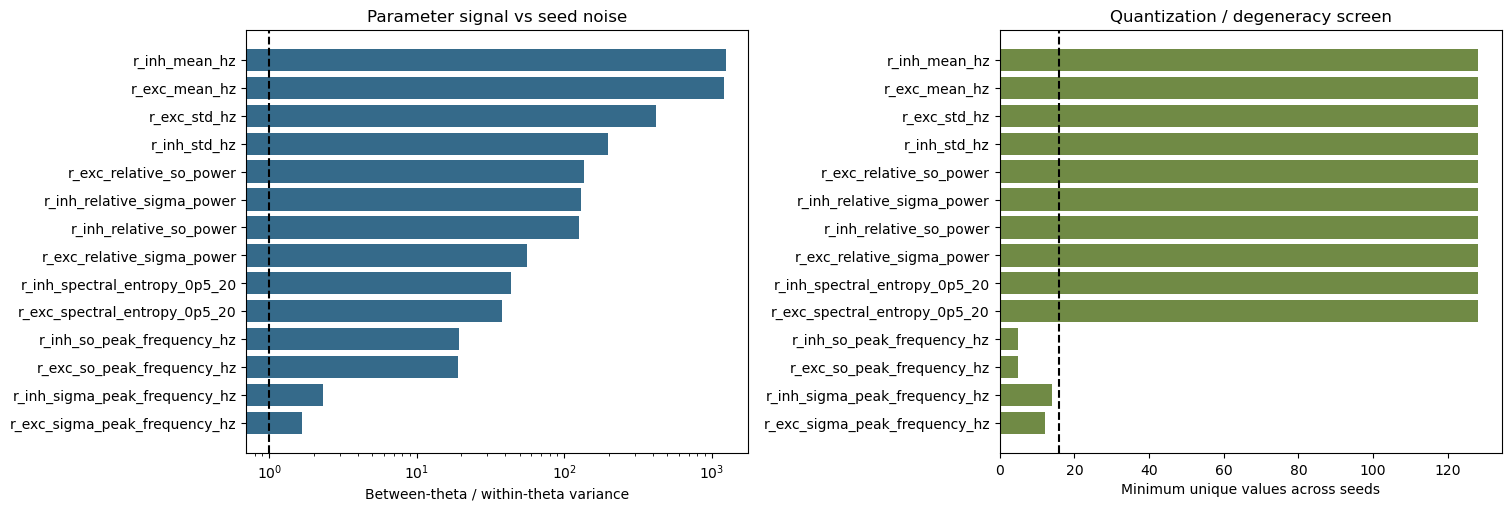

In [3]:
prior_run = run_preflight_multiseed(max_workers=6)
prior = analyze_preflight_multiseed(prior_run["path"])
display(pd.DataFrame([prior["summary"]]))
display(prior["features"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
ordered = prior["features"].sort_values("between_to_within_snr")
axes[0].barh(ordered.feature, ordered.between_to_within_snr, color="#356a8a")
axes[0].set_xscale("log")
axes[0].axvline(1, color="black", ls="--")
axes[0].set(xlabel="Between-theta / within-theta variance", title="Parameter signal vs seed noise")
axes[1].barh(ordered.feature, ordered.unique_values_min_across_seeds, color="#708a45")
axes[1].axvline(16, color="black", ls="--")
axes[1].set(xlabel="Minimum unique values across seeds", title="Quantization / degeneracy screen")
figure_dir = PREFLIGHT_ROOT / "figures"; figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / "seed_noise_and_quantization.png", dpi=180)
fig.savefig(figure_dir / "seed_noise_and_quantization.svg")
plt.show()

## Multi-scale local Jacobians

The seven free parameters are perturbed by 1%, 2%, and 5% of their unchanged
8D-prior marginal widths around V7, V8, and V8a centers under three seeds.
Effective rank uses the frozen rule \(\sigma_k/\sigma_1 \ge 10^{-3}\).
`c_ctx2th` is inserted at the same fixed value for every run.

,attempted,success,failure_rate,rank_min,rank_max,all_local_full_rank_7
0,387,387,0.0,7,7,True


,center,scale,seed,effective_rank,condition_number,relative_singular_1,relative_singular_2,relative_singular_3,relative_singular_4,relative_singular_5,relative_singular_6,relative_singular_7
0,v7_fitted,0.01,7315101,7,19.490901,1.0,0.732480,0.668820,0.301952,0.260470,0.127647,0.051306
1,v7_fitted,0.02,7315101,7,32.535697,1.0,0.663892,0.652656,0.434554,0.248155,0.115110,0.030735
2,v7_fitted,0.05,7315101,7,16.882881,1.0,0.594913,0.464992,0.255703,0.160238,0.105417,0.059232
3,v7_fitted,0.01,7315201,7,44.734594,1.0,0.777934,0.585581,0.520271,0.224523,0.162538,0.022354
4,v7_fitted,0.02,7315201,7,24.626985,1.0,0.380049,0.346057,0.272100,0.172389,0.093568,0.040606
5,v7_fitted,0.05,7315201,7,18.500819,1.0,0.501623,0.451981,0.192555,0.176093,0.122594,0.054052
6,v7_fitted,0.01,7315301,7,28.354868,1.0,0.814093,0.533059,0.397285,0.176089,0.084077,0.035267
7,v7_fitted,0.02,7315301,7,15.698505,1.0,0.829741,0.395645,0.295237,0.202528,0.114377,0.063700
8,v7_fitted,0.05,7315301,7,28.471022,1.0,0.543247,0.445993,0.373465,0.183204,0.106784,0.035123
9,v8_fitted,0.01,7315101,7,26.175364,1.0,0.401231,0.250002,0.221601,0.181821,0.046520,0.038204


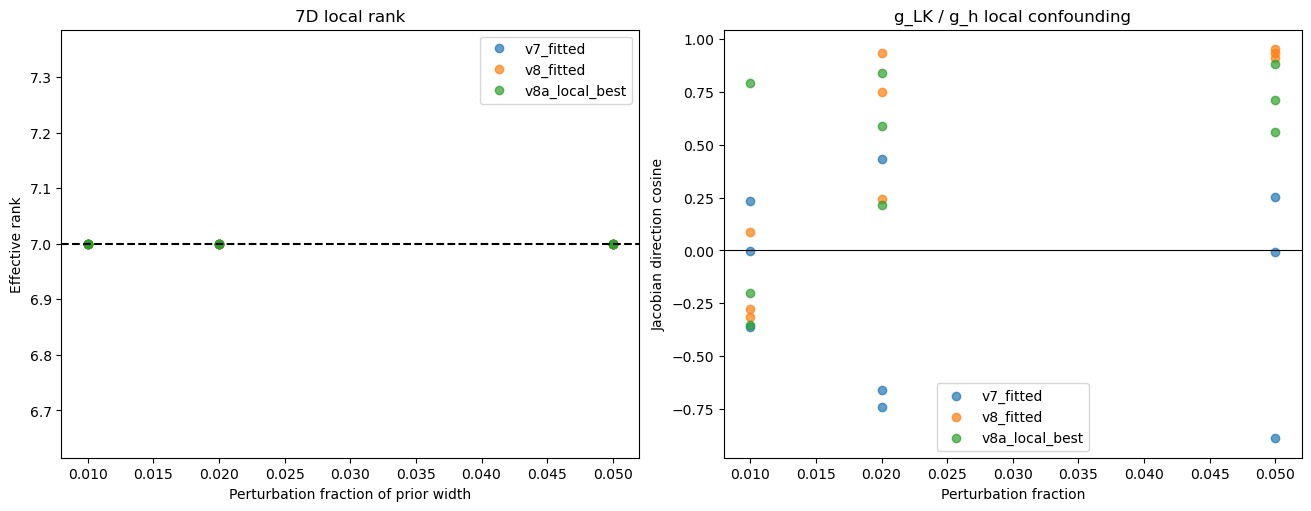

In [4]:
local_run = run_local_multiscale_7d(max_workers=6)
local = analyze_local_multiscale_7d(local_run["path"])
display(pd.DataFrame([local["summary"]]))
display(local["rank"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for center, frame in local["rank"].groupby("center"):
    axes[0].plot(frame.scale, frame.effective_rank, "o", label=center, alpha=.7)
axes[0].axhline(7, color="black", ls="--")
axes[0].set(xlabel="Perturbation fraction of prior width", ylabel="Effective rank", title="7D local rank")
axes[0].legend()
pair = local["pair_cosines"]
target = pair[((pair.parameter_a == "g_LK") & (pair.parameter_b == "g_h"))]
for center, frame in target.groupby("center"):
    axes[1].scatter(frame.scale, frame.cosine, alpha=.7, label=center)
axes[1].axhline(0, color="black", lw=.8)
axes[1].set(xlabel="Perturbation fraction", ylabel="Jacobian direction cosine", title="g_LK / g_h local confounding")
axes[1].legend()
fig.savefig(figure_dir / "local_rank_and_gLK_gH.png", dpi=180)
fig.savefig(figure_dir / "local_rank_and_gLK_gH.svg")
plt.show()

## Engineering hard gate

The next stage is permitted only when failures are at most 1%, at least 99% of
vectors are finite, feature order is invariant, seeds are reproducible, and
7-to-8 parameter insertion has no silent error. Local full rank is reported as
scientific evidence but is not substituted for held-out recovery.

In [5]:
gate = evaluate_preflight_gate(prior, local)
display(pd.DataFrame([gate]))
assert gate["pass"]
assert local["summary"]["rank_max"] <= 7
print("Stage-15 hard gate: PASS")

,failure_rate_max,finite_rate_min,observed_failure_rate_max,observed_finite_rate,feature_dimension_order_stable,seed_recorded_reproducible,silent_parameter_insertion_errors,pickle_free_reload,pass
0,0.01,0.99,0.0,1.0,True,True,0,True,True


Stage-15 hard gate: PASS
